In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Load & Preprocess the Data

In [2]:
%%capture
!pip install transformers datasets accelerate -q
!pip install evaluate

In [3]:
import numpy as np
import pandas as pd


In [4]:
en_train  = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/Training_Data_PolyHope-M_2025/Training Data/German_train.csv')
en_dev = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/Training_Data_PolyHope-M_2025/Training Data/German_dev.csv')
en_test = pd.read_csv('/kaggle/input/hope-speech-detection-across-multiple-languages/TestWithNoLabel/TestWithNoLabel/German_test_without_labels.csv')
en_train

,text,binary,multiclass
0,"Träume von einem sonnendurchfluteten Wald, wel...",Hope,Unrealistic Hope
1,#USER# #USER# #USER# #USER# Ich kann verstehen...,Not Hope,Not Hope
2,"#USER# #USER# Hochinteressant, als Volldepp mü...",Not Hope,Not Hope
3,#USER# Ich beneide Dich ehrlich positiv darum....,Not Hope,Not Hope
4,#USER# #USER# #USER# Auch das behauptet nieman...,Not Hope,Not Hope
...,...,...,...
11568,#USER# ich weiß nicht ob sie wirklich dachte d...,Not Hope,Not Hope
11569,#USER# Schon längst gewählt. Erststimme #USER#...,Hope,Generalized Hope
11570,"Zu hoher Flächenverbrauch, nicht ökologisch ge...",Hope,Generalized Hope
11571,"#USER# Mhh, das hört sich bei privaten Nachric...",Hope,Generalized Hope


In [5]:
len(en_dev)

4208

In [6]:
label_mapping = {'Hope': 1, 'Not Hope': 0}

en_train['binary'] = en_train['binary'].map(label_mapping)
en_dev['binary'] = en_dev['binary'].map(label_mapping)

en_train.drop(columns=['multiclass'], inplace=True)
en_dev.drop(columns=['multiclass'], inplace=True)

en_train.dropna(inplace=True)
en_dev.dropna(inplace=True)

In [7]:
en_dev

,text,binary
0,#USER# Einen schönen Abend und später eine gut...,1
1,"#USER# Es fehlt noch Erfahrung, Qualität sowie...",1
2,#USER# Aber vielleicht träumst du ja gerade sc...,0
3,#USER# #USER# Jau die CDU ist sowas von link ...,0
4,#USER# Moin Klaus 👋🤓👍💚das faellt mir auch schw...,0
...,...,...
4203,"#USER# Das glaube ich Dir sofort, daß das Dein...",0
4204,#USER# Ja gibt es … wir sind seit 28 Jahren ei...,1
4205,#USER# #USER# #USER# Da ich ihre völlig irre H...,1
4206,#USER# Lasse so ne Fahrt durch sonnige kalifor...,0


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

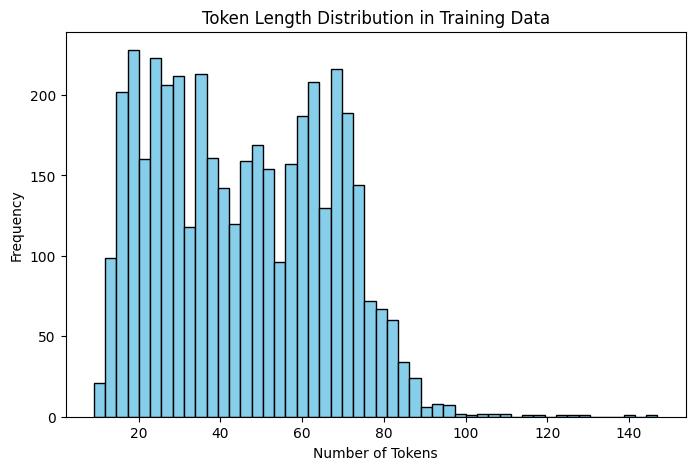

In [8]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Tokenize training data and get lengths
train_text_lengths = [len(tokenizer.tokenize(text)) for text in en_dev['text']]

# Plot the distribution
plt.figure(figsize=(8,5))
plt.hist(train_text_lengths, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.title("Token Length Distribution in Training Data")
plt.show()


In [9]:
# Use the percentile method:
Max_length = int(np.percentile(train_text_lengths, 90))  # Covers 96% of texts
Max_length

73

# Tokenization with XLM-RoBERTa

In [10]:
# Tokenization function
def tokenize_data(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=Max_length)

# Apply tokenization
train_texts = en_train["text"].tolist()
train_labels = en_train["binary"].tolist()

dev_texts = en_dev["text"].tolist()
dev_labels = en_dev["binary"].tolist()

train_encodings = tokenizer(train_texts, padding=True, truncation=True, max_length=256)
dev_encodings = tokenizer(dev_texts, padding=True, truncation=True, max_length=256)

# Convert Data to PyTorch Dataset

In [11]:
import torch

class HopeDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = HopeDataset(train_encodings, train_labels)
dev_dataset = HopeDataset(dev_encodings, dev_labels)


# Load Pre-Trained Model

In [12]:
from transformers import AutoModelForSequenceClassification

# Load the model with gradient checkpointing to save memory
model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)
model.gradient_checkpointing_enable()  # Helps with memory optimization

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#  Define Training Arguments

In [13]:
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=80,  # Keep batch size balanced
    per_device_eval_batch_size=80,
    evaluation_strategy="epoch",  # Evaluate after every epoch
    save_strategy="epoch",  # Save model after every epoch
    load_best_model_at_end=True,  # Loads best model based on F1 score
    metric_for_best_model="f1",  # Use F1 score to determine best model
    save_total_limit=3,  # Saves only the 3 best models
    num_train_epochs=100,  # Maximum epochs (but early stopping will stop before this)
    weight_decay=0.05,  # Increased from 0.01 to reduce overfitting
    learning_rate=3e-5,  # Reduced learning rate for better generalization
    logging_dir="./logs",
    logging_steps=50,  # Log every 50 steps
    report_to="none",
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# Define Metrics for Evaluation

In [14]:
import numpy as np
import evaluate

# Metrics computation
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_score = f1.compute(predictions=predictions, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}

# Initialize Trainer and Fine-Tune the Model

In [15]:
# Update dropout in model configuration
model.config.hidden_dropout_prob = 0.2  # Add dropout for hidden layers
model.config.attention_probs_dropout_prob = 0.2  # Add dropout for attention layers

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # Stops if no improvement for 2 epochs
)

# Start Training
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.382200,0.318222,0.863356,0.862091
2,0.274300,0.283285,0.872386,0.870739
3,0.208000,0.299670,0.877376,0.875801
4,0.160900,0.331517,0.876426,0.874479
5,0.108100,0.406066,0.873574,0.872227


TrainOutput(global_step=725, training_loss=0.23326586920639564, metrics={'train_runtime': 1860.5736, 'train_samples_per_second': 622.012, 'train_steps_per_second': 7.793, 'total_flos': 7196154169637400.0, 'train_loss': 0.23326586920639564, 'epoch': 5.0})

# Evaluate the Model

In [16]:
trainer.evaluate()


{'eval_loss': 0.2996700704097748,
 'eval_accuracy': 0.8773764258555133,
 'eval_f1': 0.8758005393709443,
 'eval_runtime': 18.2231,
 'eval_samples_per_second': 230.915,
 'eval_steps_per_second': 2.908,
 'epoch': 5.0}

# Save the Model

In [17]:
# Save the fine-tuned model
output_dir = "/kaggle/working/xlm-roberta-hope"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('/kaggle/working/xlm-roberta-hope/tokenizer_config.json',
 '/kaggle/working/xlm-roberta-hope/special_tokens_map.json',
 '/kaggle/working/xlm-roberta-hope/sentencepiece.bpe.model',
 '/kaggle/working/xlm-roberta-hope/added_tokens.json',
 '/kaggle/working/xlm-roberta-hope/tokenizer.json')

In [18]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

# Load Model & Tokenizer
model_path = "/kaggle/working/xlm-roberta-hope"  # Update path if needed
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()  # Set to evaluation mode

# Move Model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Ensure 'en_test' DataFrame exists
if "en_test" not in globals():
    raise ValueError("❌ 'en_test' DataFrame is not defined.")

test_texts = en_test["text"].tolist()  # Ensure 'text' column exists in test CSV

# Tokenization (optimized for GPU)
max_length = 85  # Use a fixed length to optimize padding
encoded_inputs = tokenizer(
    test_texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt"
)

# Keep tensors on CPU initially for DataLoader compatibility
input_ids = encoded_inputs["input_ids"]  # Keep as LongTensor
attention_mask = encoded_inputs["attention_mask"]  # Will move to GPU later

# Define batch size to avoid OOM
batch_size = 16  # Adjust based on available GPU memory
dataset = TensorDataset(input_ids, attention_mask)
dataloader = DataLoader(dataset, batch_size=batch_size)  # ❌ Removed pin_memory=True

# Prediction Loop with Memory Optimization
predictions = []
with torch.no_grad():
    for batch in dataloader:
        input_ids, attention_mask = batch

        # Move tensors to GPU inside the loop
        input_ids = input_ids.to(device, dtype=torch.long)
        attention_mask = attention_mask.to(device, dtype=torch.float16)  # Optional for optimization

        # Mixed Precision with Correct autocast
        with torch.amp.autocast("cuda"):  
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            batch_predictions = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(batch_predictions)
        
        # Clear cache to prevent memory overflow
        torch.cuda.empty_cache()

# Convert Predictions to Original Labels
label_map = {0: "Not Hope", 1: "Hope"}
predicted_labels = [label_map[pred] for pred in predictions]

# Save Predictions to CSV
submission_df = pd.DataFrame({"Text": test_texts, "Tag": predicted_labels})
submission_df.to_csv("predictions.csv", index=False)

print("✅ Predictions successfully saved to 'predictions.csv' using GPU.")


✅ Predictions successfully saved to 'predictions.csv' using GPU.
